### The goal of self-attention is to compute a context vector, for each input element, that combines information from all other input elements.

#### A context vector can be interpreted as an enriched embedding vector.

####  This enhanced context vector, z(2), is an embedding that contains information about x(2) and all other input elements x(1) to x(T).

# Input Vector

In [9]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

# Compute Simple Self-Attention

## Calculate attention scores

In [5]:
# Calculate attention scores

query = inputs[1] # journey  (x^2)
# print(query)
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


## obtain attention weights

### Basic - using sum

In [7]:
# obtain attention weights
# by normalizing the attention scores

attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


### Naive - Using Exp function

In [11]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
 
attn_weights_2_naive = softmax_naive(attn_scores_2)
print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


### Efficient - Using Pytorch's softmax function

In [12]:
# Using Pytorch's softmax function
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


## Create Context Vector

### For a single input

In [17]:
query = inputs[1] # 2nd input token is the query
context_vec_2 = torch.zeros(query.shape)
print("context vector: ", context_vec_2)
for i,x_i in enumerate(inputs):
    # print("x_i: ",x_i)
    context_vec_2 += attn_weights_2[i] * x_i
print(context_vec_2)
# print(torch.softmax(context_vec_2, dim=0))

context vector:  tensor([0., 0., 0.])
tensor([0.4419, 0.6515, 0.5683])


### Generalize to calculate all Context vector simultaneously

#### Compute Attention Scores

#####  using dot product

In [18]:
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


##### using Matrix Multiplication

In [19]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


#### Compute Attention Weights

In [44]:
# dim=-1 will normalize across the columns, 
# so that the values in each row (summing over the column dimension) sum up to 1.
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [42]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [46]:
# this is just to test if we do the softmax on dim = 0
# then each column would sum to 0
col_3 = attn_weights[:,2]
sum(col_3)

tensor(1.2788)

#### Compute Context Vectors

In [47]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


# Compute Attention with Trainable Weights

Trainable weight matrices in self-attention mechanisms, such as those used in large language models (LLMs), are crucial for transforming input data into queries, keys, and values, allowing the model to learn and produce effective context vectors during training

In [48]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

## initialize the three weight matrices Wq, Wk, and Wv 

In [57]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [53]:
query_2 = x_2 @ W_query 
key_2 = x_2 @ W_key 
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [68]:
keys = inputs @ W_key 
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


### Compute the Attention Score W<sub>22</sub>

In [61]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


### All attention scores for given query

In [60]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [65]:
d_k = keys.shape[-1]
print(d_k)
attn_scores_2_scaled = attn_scores_2 / d_k**0.5
attn_weights_2 = torch.softmax(attn_scores_2_scaled, dim=-1)
print(attn_weights_2)

2
tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [66]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


### A compact self-attention class

In [ ]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.d_out = d_out
        # weight initialization
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
 
    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [ ]:
torch.manual_seed(123)
# sa_v1 = SelfAttention_v1(d_in, d_out)

# passing SelfAttention_V2 weight to SelfAttention_V1
sa_v1.W_query = torch.nn.Parameter(sa_v2.W_query.weight.T)
sa_v1.W_key = torch.nn.Parameter(sa_v2.W_key.weight.T)
sa_v1.W_value = torch.nn.Parameter(sa_v2.W_value.weight.T)

print(sa_v1(inputs))

In [ ]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        # weight initialization
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
 
    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [ ]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

# Making Enhancements to Attention Mechanism
* Causal
* Multi-head element


#### Causal
To prevent the model from accessing future information in the sequence

#### Multi-head
- Each head learns different aspects of the data
- allows model to simultaneously attend to information from different representation subspaces at different position
- improves models' performance in complex tasks

### Applying a causal attention mask

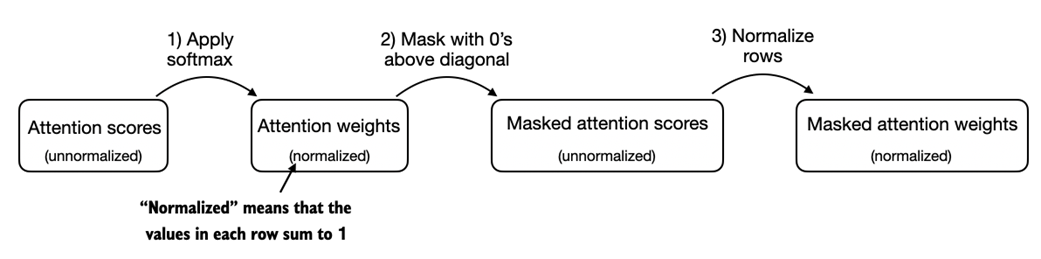


In [ ]:
# 1. Apply Softmax on Attention Scores

queries= sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim = 1)
print(attn_weights)

In [ ]:
# 2. Mask with 0's above diagonal

context_length = attn_weights.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
# mask_simple
# attn_weight_masked = torch.tril(attn_weights)
attn_weight_masked = attn_weights * mask_simple
attn_weight_masked

In [ ]:
# 3. Renormalize attention weights

row_sums = attn_weight_masked.sum(dim=1, keepdim = True)
attn_weight_masked_norm = attn_weight_masked / row_sums
print(attn_weight_masked_norm)

In [ ]:
# Efficient Masking for Causal Attention

mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

In [ ]:
context_length = 6
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
mask.bool()